# 📷 AI-Based Photo Quality Classification Using Machine Learning

This project uses **Machine Learning** to classify photos into **High Quality** and **Low Quality**.

TensorFlow and Artificial Neural Networks are not used.

## 1. Import Required Libraries

Import the libraries needed for image processing and machine learning.

In [13]:
import os
import numpy as np
from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

## 2. Load and Preprocess Images

Resize each image to 64×64, convert it into RGB, flatten the pixels, and scale pixel values between 0 and 1.

In [14]:
X = []
y = []

for label, folder in [(1, 'High_Quality'), (0, 'Low_Quality')]:
    for file in os.listdir(folder):
        path = os.path.join(folder, file)
        try:
            img = Image.open(path).convert('RGB')
            img = img.resize((64, 64))
            X.append(np.array(img).flatten() / 255.0)
            y.append(label)
        except:
            pass

X = np.array(X)
y = np.array(y)

print('X shape:', X.shape)
print('y shape:', y.shape)

X shape: (200, 12288)
y shape: (200,)


## 3. Split the Dataset

Split the images into training and testing data.

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print('Training data:', X_train.shape)
print('Testing data:', X_test.shape)

Training data: (160, 12288)
Testing data: (40, 12288)


## 4. Create the Machine Learning Model

Logistic Regression is used as a binary classification model for High Quality and Low Quality photos.

In [16]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

print('Model Training Completed')

Model Training Completed


## 5. Predict Photo Quality

Use the trained model to predict the quality of test images.

In [17]:
y_pred = model.predict(X_test)

print('Predictions:', y_pred[:10])

Predictions: [0 1 1 1 0 1 0 1 1 0]


## 6. Evaluate Model Accuracy

Calculate the accuracy of the Machine Learning model.

In [18]:
accuracy = accuracy_score(y_test, y_pred)
print('Model Accuracy:', accuracy)
print('Accuracy in %:', round(accuracy * 100, 2), '%')

Model Accuracy: 1.0
Accuracy in %: 100.0 %


## 7. Classification Report

Check precision, recall, and F1-score for both photo-quality classes.

In [19]:
print(classification_report(
    y_test,
    y_pred,
    target_names=['Low Quality', 'High Quality']
))

              precision    recall  f1-score   support

 Low Quality       1.00      1.00      1.00        20
High Quality       1.00      1.00      1.00        20

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.00        40
weighted avg       1.00      1.00      1.00        40



## 8. Confusion Matrix

The confusion matrix shows correct and incorrect classifications.

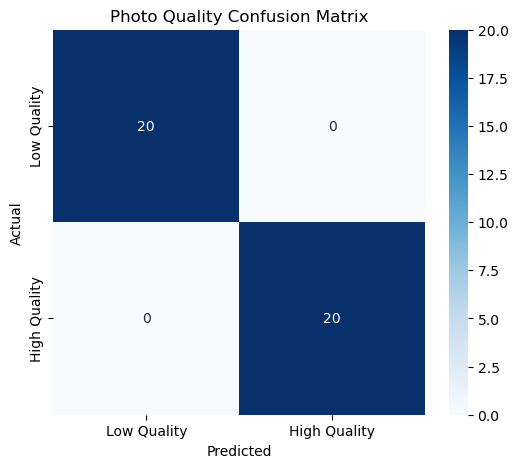

In [20]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Low Quality', 'High Quality'],
    yticklabels=['Low Quality', 'High Quality']
)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Photo Quality Confusion Matrix')
plt.show()

## 9. Predict a Single Image

Load one new image, preprocess it in the same way, and predict its quality.

In [21]:
import os
import random
from PIL import Image
import numpy as np

# Select a random image from High_Quality or Low_Quality folder
folder = random.choice(["High_Quality", "Low_Quality"])

files = [
    f for f in os.listdir(folder)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
]

image_file = random.choice(files)
image_path = os.path.join(folder, image_file)

print("Testing Image:", image_path)

# Load and preprocess image
img = Image.open(image_path).convert("RGB")
img = img.resize((64, 64))

img_array = np.array(img).flatten() / 255.0
img_array = img_array.reshape(1, -1)

# Prediction
prediction = model.predict(img_array)[0]

if prediction == 1:
    print("Photo Quality: High Quality")
else:
    print("Photo Quality: Low Quality")

Testing Image: Low_Quality\low_039.jpg
Photo Quality: Low Quality


## 10. Save the Trained ML Model

Save the Logistic Regression model using Pickle so it can be used later in a Streamlit application.

In [22]:
with open('photo_quality_ml.pkl', 'wb') as file:
    pickle.dump(model, file)

print('ML model saved successfully')

ML model saved successfully


## 11. Load the Saved Model

Load the saved model and use it for prediction.

In [23]:
with open('photo_quality_ml.pkl', 'rb') as file:
    loaded_model = pickle.load(file)

result = loaded_model.predict(img_array)[0]

print('High Quality' if result == 1 else 'Low Quality')

Low Quality


In [24]:
import pickle

with open("photo_quality_ml.pkl", "wb") as file:
    pickle.dump(model, file)

print("Model saved successfully!")

Model saved successfully!
